In [1]:
import os
os.chdir('..')

# Import Files

In [2]:
import matplotlib.pyplot as plt

from util.features import *
from src.data_io import *
from src.models import *
from src.pca_harx import *
from src.volatility_estimates import *

In [3]:
tmp_dfs = []
for exo_data_file in os.listdir('./dataset'):
    if not exo_data_file.endswith('.csv'):
        continue
    
    name = os.path.join('./dataset', exo_data_file)
    tmp = pd.read_csv(name, index_col='date', thousands=',')
    tmp.index = pd.to_datetime(tmp.index, format='%d/%m/%Y')
    tmp_dfs.append(tmp)

# Download Data
In the section below, we will be using Alpaca Client to get the intraday 5min candlestick data. However, the issue is that we can only access data after about 2016. Therefore, our evaluation can only begin from the same start point.

In [4]:
symbol = 'SPY'
start_date = '2010-01-01' #A little extra data points for calculation purposes.
end_date = '2025-12-31'

params = {
    'symbol': symbol,
    'start_date': start_date,
    'end_date': end_date,
    'interval': '1d'
}
yf = YahooFinance(**params)
df = yf.pipeline()
df.head(5)

[*********************100%***********************]  1 of 1 completed


Price,date,Adj Close,Close,High,Low,Open,Volume,log_return
0,2010-01-04,85.027939,113.330002,113.389999,111.510002,112.370003,118944600,NaN
1,2010-01-05,85.253052,113.629997,113.680000,112.849998,113.260002,111579900,0.002644
2,2010-01-06,85.313057,113.709999,113.989998,113.430000,113.519997,116074400,0.000704
3,2010-01-07,85.673164,114.190002,114.330002,113.180000,113.500000,131091100,0.004212
4,2010-01-08,85.958282,114.570000,114.620003,113.660004,113.889999,126402800,0.003322


In [5]:
df['garman_klass'] = VolatilityMeasures(df).garman_klass_volatility(df['Close'], df['High'], df['Low'], df['Open'])
df.head(5)

Price,date,Adj Close,Close,High,Low,Open,Volume,log_return,garman_klass
0,2010-01-04,85.027939,113.330002,113.389999,111.510002,112.370003,118944600,NaN,0.010574
1,2010-01-05,85.253052,113.629997,113.680000,112.849998,113.260002,111579900,0.002644,0.004769
2,2010-01-06,85.313057,113.709999,113.989998,113.430000,113.519997,116074400,0.000704,0.003324
3,2010-01-07,85.673164,114.190002,114.330002,113.180000,113.500000,131091100,0.004212,0.006075
4,2010-01-08,85.958282,114.570000,114.620003,113.660004,113.889999,126402800,0.003322,0.004656


In [6]:
train_df = df.loc[:, ['garman_klass', 'log_return', 'date']]
train_df.set_index('date', drop=True, inplace=True)
train_df.tail(5)

Price,garman_klass,log_return
date,,
2025-12-23,0.002553,0.004560
2025-12-24,0.002204,0.003511
2025-12-26,0.002429,-0.000101
2025-12-29,0.003206,-0.003570
2025-12-30,0.001997,-0.001222


# Model Backtesting

In [7]:
#R-GARCH
log_returns = train_df.loc[:, 'log_return'].dropna()
r_garch = OptimizedRGARCH(log_returns*100)
r_garch_backtest = r_garch.backtest()
r_garch_backtest['preds'] /= 100
r_garch_backtest.head(5)

,mu,omega,alpha[1],beta[1],nu,preds
date,,,,,,
2013-12-24,0.111810,0.034444,0.130537,0.844938,5.316491,0.007784
2013-12-26,0.111774,0.033648,0.128646,0.846946,5.332677,0.007385
2013-12-27,0.112449,0.033049,0.127263,0.848282,5.367088,0.007165
2013-12-30,0.112069,0.032498,0.126359,0.849291,5.373690,0.006845
2013-12-31,0.111781,0.032051,0.125911,0.849797,5.382210,0.006562


In [8]:
#HAR
volatility_measure = train_df.loc[:, ['garman_klass']]
har = DirectHAR(volatility_measure)
har_backtest = har.backtest(horizon=1)
har_backtest.head(5)

,beta_prev_day,beta_weekly_rolling_avg,beta_monthly_rolling_avg,intercept,y_hat,target
date,,,,,,
2014-01-27,0.278509,0.240179,0.348405,0.000937,0.005148,0.008787
2014-01-28,0.279150,0.239870,0.346794,0.000949,0.006267,0.003365
2014-01-29,0.278684,0.237039,0.350372,0.000937,0.004628,0.006596
2014-01-30,0.279207,0.237413,0.349140,0.000943,0.005809,0.005962
2014-01-31,0.279470,0.236345,0.349355,0.000944,0.005702,0.008472


In [9]:
#PCA HAR-X
exo_symbols = ['^VIX', '^VVIX', '^MOVE', '^GVZ', '^OVX']
exo_df = []
for s in exo_symbols:
    params = {
        'symbol': s,
        'start_date': start_date,
        'end_date': end_date,
        'interval': '1d'
    }
    tmp = YahooFinance(**params)
    tmp_df = tmp.pipeline()
    tmp = format_yf_df(tmp_df)
    tmp.columns = [s]
    exo_df.append(tmp)

exo_df = pd.concat(exo_df, axis=1)
exo_df.index = pd.to_datetime(exo_df.index, format='%d/%m/%Y')
exo_df = exo_df.sort_index(ascending=True)
scaled_exo_df = np.log(exo_df/ exo_df.shift(1))

pca_harx = PCADirectHARX(volatility_measure, scaled_exo_df)
pca_harx_backtest = pca_harx.backtest(horizon=1)
pca_harx_backtest.head(5)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


,beta_prev_day,beta_weekly_rolling_avg,beta_monthly_rolling_avg,beta_market_vol_structure,beta_cross_asset_vol_structure,intercept,y_hat,target
date,,,,,,,,
2014-04-10,0.246417,0.314828,0.327734,0.000253,0.000902,0.000808,0.007545,0.009450
2014-04-11,0.244899,0.318575,0.325835,0.000262,0.000903,0.000808,0.008433,0.007893
2014-04-14,0.245157,0.316089,0.327578,0.000265,0.000899,0.000805,0.007371,0.007482
2014-04-15,0.245831,0.315820,0.327361,0.000266,0.000898,0.000806,0.007453,0.010487
2014-04-16,0.246054,0.315296,0.326725,0.000263,0.000903,0.000812,0.007015,0.005237


# Comparison to High-Frequency Realized Volatility
For our target variable, we will calculate the realized volatility using a high-frequency estimator as denoted in the paper by:

$RV_t = \sqrt{\sum^M_{i=1}r^2_{t, i}}$

where $r_{t,i}$ represents the $i$-th intraday return on trading day $t$.

## Alpaca Client

In order to get the intraday data, we will be using Alpaca Markets. Refer to the following documentation: https://docs.alpaca.markets/reference/stockbars

Consequently, we need to create a free account and generate the API Key and Secret Key to access the data. A "secrets.env" file must be created in the parent folder, with the following values:
- ALPACA_KEY=API_KEY
- ALPACA_SECRET=SECRET_KEY

Note that the earliest available data starts from 2016, so we are unable to replicate the paper faithfully.

In [10]:
from dotenv import load_dotenv
load_dotenv("secrets.env")
ALPACA_KEY = os.getenv("ALPACA_KEY")
ALPACA_SECRET = os.getenv("ALPACA_SECRET")

In [11]:
alpaca_client = AlpacaStockData(api_key=ALPACA_KEY, secret_key=ALPACA_SECRET)
intraday_df = alpaca_client.get_stock_bar(symbol=symbol, start=start_date, end=end_date)
intraday_df.index = intraday_df.index.droplevel(0)
intraday_df.head(5)

,open,high,low,close,volume,trade_count,vwap
timestamp,,,,,,,
2016-01-01 00:00:00+00:00,204.05,204.08,204.05,204.08,500.0,6.0,204.057500
2016-01-01 00:05:00+00:00,204.01,204.05,204.01,204.05,750.0,3.0,204.024430
2016-01-01 00:10:00+00:00,204.09,204.09,204.01,204.01,350.0,2.0,204.032857
2016-01-01 00:45:00+00:00,204.04,204.04,204.04,204.04,300.0,2.0,204.040000
2016-01-01 00:50:00+00:00,204.02,204.07,204.02,204.07,650.0,3.0,204.031538


In [12]:
def intraday_rv(intraday_df:pd.DataFrame, date_format:str='%d/%m/%Y') -> pd.Series:
    df = intraday_df.copy()
    df['log_returns'] = np.log(df['close']).diff()
    rv = (
        df['log_returns'].dropna()
        .pow(2)
        .resample("1D")
        .sum()
    )
    rv.name = 'realized_volatility'
    rv.index = pd.to_datetime(rv.index, format=date_format).tz_localize(None).normalize() #Standardize date format to be tz-naive
    return np.sqrt(rv)

target_rv = intraday_rv(intraday_df)

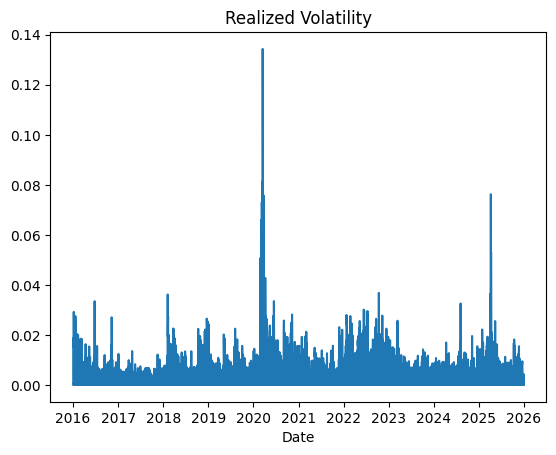

In [14]:
plt.plot(target_rv)
plt.title("Realized Volatility")
plt.xlabel("Date")
plt.show()

## Performance Measures
Quasi-Likelihood (QLIKE) is a way to do likelihood-based estimation and inference without fully specifying the true data distribution. This is useful as the true distribution for volatility is unknown, and if we were to infer the distribution, it would typically be time-varying, non-Gaussian, and with heavy-tails. The classical notation is denoted as:
$$QLIKE = \frac{RV_t}{F_t} + logF_t + c$$

From the equation, we can observe that the loss function penalizes under-forecast more than over-forecast. It also ensures that one cannot cheat by forecasting an absurdly high value through the $logF_t$ term. Overall, this is perfect for volatility where we are typically more concerned with missing volatility spikes.

Note that the $logF_t$ can be rewritten in the following form:
$$logF_t = logRV_t - log\frac{RV_t}{F_t}$$

Since $logRV_t$ will be a constant between models, it does not affect our model comparison and hence can be dropped. After substitution, we get the following:
$$QLIKE = \frac{RV_t}{F_t} - log\frac{RV_{t}}{F_t} + c$$

Lastly, if $RV_t = F_t$ we will have $1-0+c = 1+c$, and therefore, for convenience we can set $c = -1$:
$$QLIKE = \frac{RV_t}{F_t} - log\frac{RV_{t}}{F_t} - 1$$

Staying true to the paper, we will use the Mean Squared Error (MSE) and QLIKE to assess out-of-sample forecast accuracy. These are defined as:
$$MSE=\frac{1}{T}\sum^T_{t=1}\left(RV_{t+h-1|t} - F_t\right)^2$$
$$QLIKE = \frac{1}{T}\sum^T_{t=1}\left(\frac{RV_{t+h-1|t}}{F_t} - log\frac{RV_{t+h-1|t}}{F_t}-1\right)$$
$$RV_{t+h-1|t} = \frac{1}{h}\sum^{t+h-1}_{i=t}RV_i, \quad h \geq 1$$
where $T$ is the number of forecasts and $F_t$ is the forecast.

In [31]:
def mean_squared_error(actual:pd.Series, forecast:pd.Series) -> float:
    squared_error = (actual - forecast)**2
    return np.mean(squared_error)

def qlike(actual:pd.Series, forecast:pd.Series) -> float:
    #For stability
    mask = (actual > 0) & (forecast > 0)
    actual = actual[mask]
    forecast = forecast[mask]
    
    diff = actual/forecast
    error = (diff - np.log(diff) - 1)
    return np.mean(error)

In [16]:
def get_actual_forecast(eval_df:pd.DataFrame) -> tuple:
    actual = eval_df.iloc[:, 1]
    forecast = eval_df.iloc[:, 0]
    return actual, forecast

def print_metrics(actual, forecast):
    garch_mse = mean_squared_error(actual, forecast)
    garch_qlike = qlike(actual, forecast)
    print(f"MSE: {garch_mse}\nQLIKE: {garch_qlike}")

def plot_comparison(actual, forecast, title) -> plt.Figure:
    plt.plot(forecast, color='red', label='predicted')
    plt.plot(actual, color='black', alpha=0.5, label='target')
    plt.title(title) 
    plt.ylabel("Volatility")
    plt.xlabel("Dates")
    fig = plt.gcf()
    fig.set_size_inches(20,5)
    plt.legend()
    return fig

# Backtest Results

MSE: 2.0501755376811247e-05
QLIKE: 0.06963316638592097


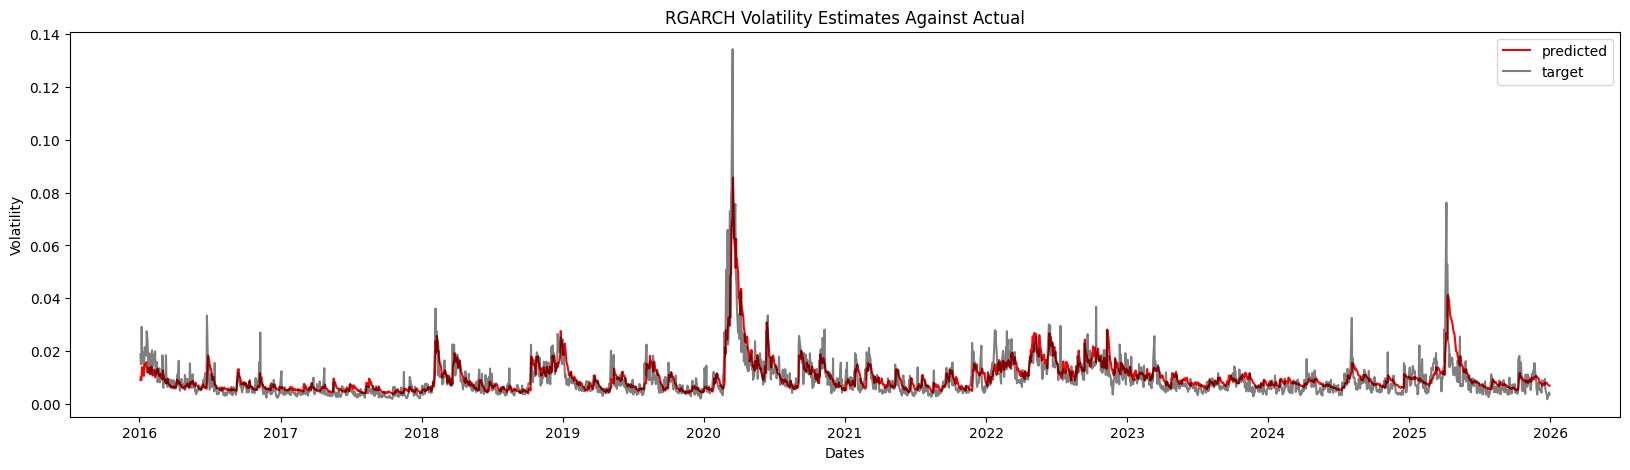

In [32]:
garch_eval_df = pd.concat([r_garch_backtest['preds'], target_rv], axis=1, join='inner')
actual, forecast = get_actual_forecast(garch_eval_df)
print_metrics(actual, forecast)
plot_comparison(actual, forecast, "RGARCH Volatility Estimates Against Actual")
plt.show()

MSE: 2.7491935987320932e-05
QLIKE: 0.1041245084295337


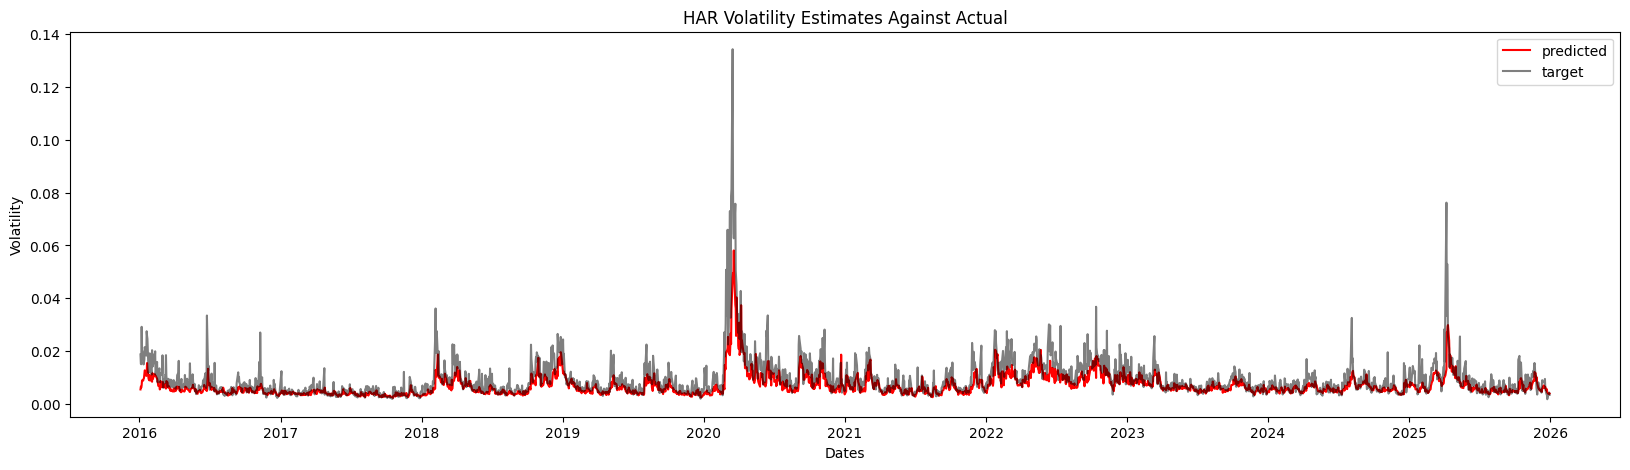

In [33]:
har_eval_df = pd.concat([har_backtest['y_hat'], target_rv], axis=1, join='inner')
actual, forecast = get_actual_forecast(har_eval_df)
print_metrics(actual, forecast)
plot_comparison(actual, forecast, "HAR Volatility Estimates Against Actual")
plt.show()

MSE: 2.6119626507640223e-05
QLIKE: 0.11234934094725978


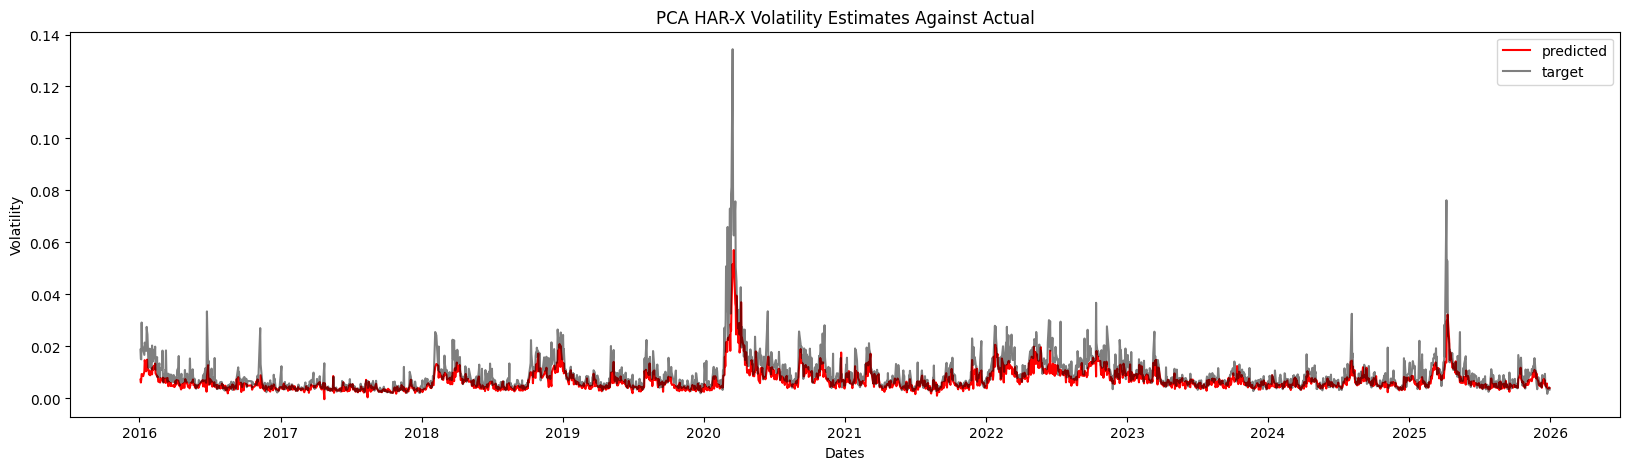

In [34]:
harx_eval_df = pd.concat([pca_harx_backtest['y_hat'], target_rv], axis=1, join='inner')
actual, forecast = get_actual_forecast(harx_eval_df)
print_metrics(actual, forecast)
plot_comparison(actual, forecast, "PCA HAR-X Volatility Estimates Against Actual")
plt.show()

Note that RGARCH is good at forecasting at higher volatility levels and appears alot smoother than the HAR-based models. However, the HAR-based models are better at the lower levels and mimic the movement of volatility better. Therefore, one could potentially explore the average of the two as the predicted value.

MSE: 1.931837832010174e-05
QLIKE: 0.06315100774500401


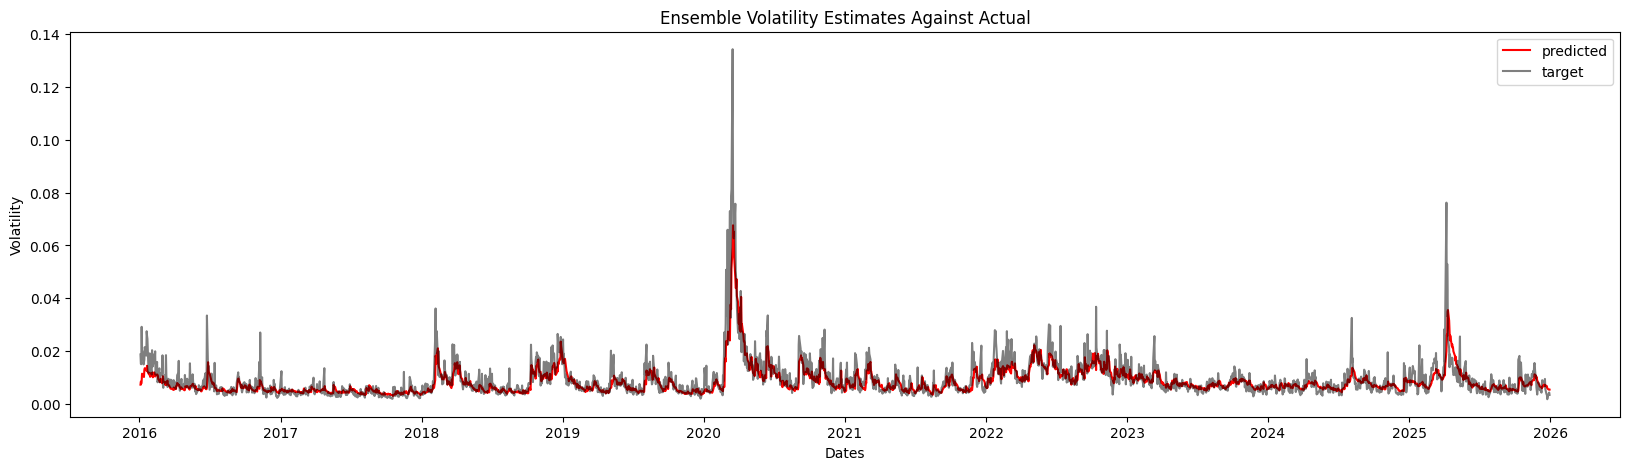

In [46]:
ensemble = pd.concat([r_garch_backtest['preds'], har_backtest['y_hat'], target_rv], axis=1, join='inner')
ensemble['total_pred'] = (ensemble['preds'] + ensemble['y_hat'])/2
ensemble = ensemble.loc[:, ['total_pred', 'realized_volatility']]
actual, forecast = get_actual_forecast(ensemble)
print_metrics(actual, forecast)
plot_comparison(actual, forecast, "Ensemble Volatility Estimates Against Actual")
plt.show()

MSE: 1.8321058247124314e-05
QLIKE: 0.0569697123023738


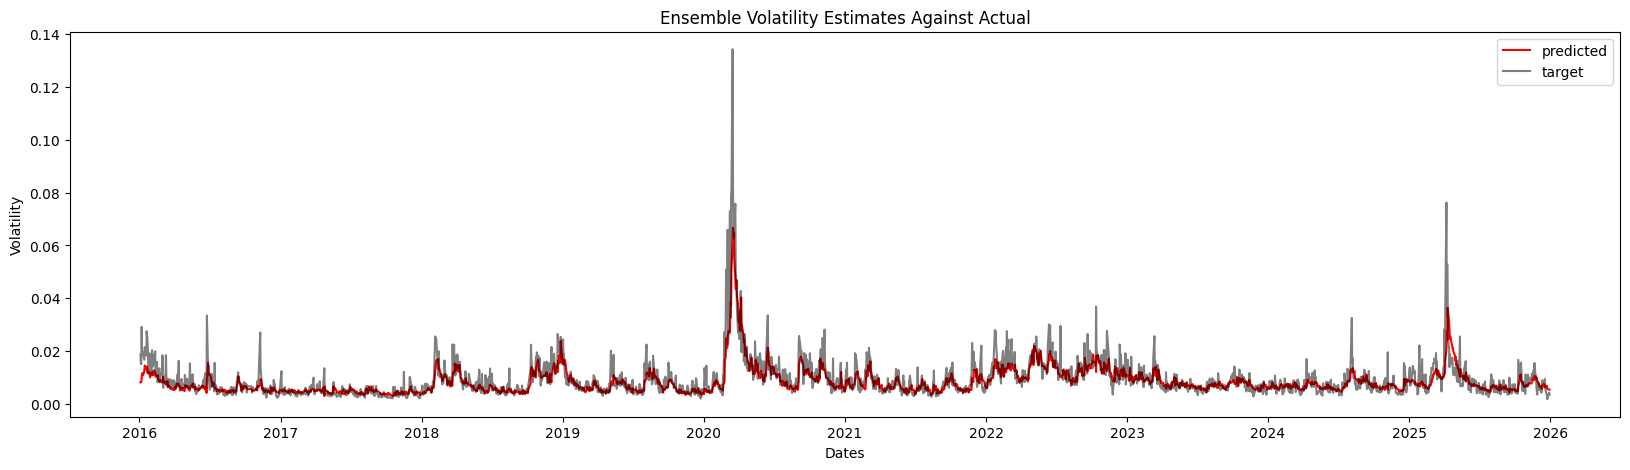

In [47]:
ensemble_2 = pd.concat([r_garch_backtest['preds'], pca_harx_backtest['y_hat'], target_rv], axis=1, join='inner')
ensemble_2['total_pred'] = (ensemble_2['preds'] + ensemble_2['y_hat'])/2
ensemble_2 = ensemble_2.loc[:, ['total_pred', 'realized_volatility']]
actual, forecast = get_actual_forecast(ensemble_2)
print_metrics(actual, forecast)
plot_comparison(actual, forecast, "Ensemble Volatility Estimates Against Actual")
plt.show()